*Code was partially completed using Claude*

# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [2]:
from netml.pparser.parser import PCAP

ndf = PCAP('../notebooks/data/netflix.pcap')

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [3]:
from scapy.all import rdpcap
from scapy.layers.dns import DNS, DNSRR
from scapy.layers.inet import IP
from scapy.utils import wrpcap

packets = rdpcap('../notebooks/data/netflix.pcap')

netflix_ips = set()
for pkt in packets:
    if pkt.haslayer(DNS) and pkt[DNS].qr == 1:
        i = 1
        while True:
            rr = pkt.getlayer(DNSRR, i)
            if rr is None:
                break
            rrname = rr.rrname.decode() if isinstance(rr.rrname, bytes) else rr.rrname
            if rr.type == 1 and 'nflx' in rrname.lower():
                netflix_ips.add(rr.rdata)
            i += 1

print(netflix_ips)

netflix_packets = [
    pkt for pkt in packets
    if pkt.haslayer(IP) and (pkt[IP].src in netflix_ips or pkt[IP].dst in netflix_ips)
]
wrpcap('netflix_only.pcap', netflix_packets)
print(f"{len(netflix_packets)} Netflix packets written")

{'198.38.120.134', '198.38.120.153', '198.38.120.167', '198.38.120.162', '198.38.120.164', '198.38.120.130', '198.38.120.137', '198.38.120.166'}
137274 Netflix packets written


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [4]:
from netml.pparser.parser import PCAP

pcap = PCAP('netflix_only.pcap')
pcap.pcap2pandas()
ndf = pcap.df

ndf.head()

,datetime,dns_query,dns_resp,ip_dst,ip_dst_int,ip_src,ip_src_int,is_dns,length,mac_dst,mac_dst_int,mac_src,mac_src_int,port_dst,port_src,protocol,time,time_normed
0,2018-02-11 15:10:02,None,None,198.38.120.130,3324409986,192.168.43.72,3232246600,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443,58451,TCP,1518358202.903273,0.000000
1,2018-02-11 15:10:02,None,None,198.38.120.130,3324409986,192.168.43.72,3232246600,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443,58452,TCP,1518358202.903319,0.000046
2,2018-02-11 15:10:02,None,None,198.38.120.130,3324409986,192.168.43.72,3232246600,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443,58453,TCP,1518358202.903415,0.000142
3,2018-02-11 15:10:02,None,None,198.38.120.153,3324410009,192.168.43.72,3232246600,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443,58464,TCP,1518358202.904561,0.001288
4,2018-02-11 15:10:02,None,None,198.38.120.153,3324410009,192.168.43.72,3232246600,False,78,a0:ce:c8:0d:2b:a7,176809980013479,e4:ce:8f:01:4c:54,251575813622868,443,58465,TCP,1518358202.904633,0.001360


In [ ]:
def mean():
    return ndf['length'].mean()

def median():
    return ndf['length'].median()

def std():
    return ndf['length'].std()

def iqr():
    return ndf['length'].quantile(0.75) - ndf['length'].quantile(0.25)

def avg_duration():
    return ndf['time_normed'].mean()

print(f"Average packet length: {mean()}")
print(f"Median packet length: {median()}")
print(f"Packet standard deviation: {std()}")
print(f"Packet interquartile range: {iqr()}")
print(f"Average packet arrival duration: {avg_duration()}")

Average packet length: 150.0457624896193
Median packet length: 200.0
Packet standard deviation: 64.22115786083394
Packet interquartile range: 134.0
Average packet duration: 176.8507776028891


**Write a brief justification for the features that you have chosen.**

Mean - Shows the average amount of data carried per packet

Median - With mean, gives a better representation of the data without possible outliers

Standard deviation - similar as mean and median, shows the variability of the packet sizes, adds more information and detail

Interquartile Range - A better measure of the spread of the data than standard deviation

Average Packet Arrival Duration - Captures how fast the packets are moving/how the video is actually loading.




### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [6]:
window = 10  # seconds

ndf["window"] = (ndf["time_normed"] // window).astype(int)   # replace "time" with real column name

def segment_download_rate(window_df, gap_threshold=0.5):
    times = sorted(window_df["time_normed"])
    if not times:
        return 0
    segments = 1
    for i in range(1, len(times)):
        if times[i] - times[i-1] > gap_threshold:
            segments += 1
    return segments

ndf.groupby("window").apply(segment_download_rate)

window
0     3
1     5
2     3
3     2
4     2
5     1
6     1
7     1
8     1
9     5
10    7
11    6
12    4
13    7
14    7
15    2
16    1
17    3
18    2
19    3
20    4
21    3
22    3
23    2
24    3
25    2
26    2
27    2
28    3
29    3
30    3
31    1
32    3
33    2
34    2
35    4
36    5
37    1
38    5
39    3
40    3
41    5
42    2
43    1
44    5
45    4
46    4
47    5
48    3
49    1
dtype: int64

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [7]:
import pandas as pd
# vds = pd.read_pickle('../notebooks/data/netflix_dataset.pkl')
vds = pd.read_pickle('../notebooks/data/netflix_dataset.pkl')


vds.head(20)

,10_EWMA_chunksizes,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,...,userTwoRetransmit,userUrgFlags,userXRetransmit,userZeroRetransmit,service,startup3.3,startup6.6,startup5,startup10,startup_mc
208,"[[4380.0], [4380.0], [19682.095238095237], [23...",148947.1,43473.0,43473.0,185098.0,185098.0,361832.3,361832.3,461040.2,461040.2,...,0.0,0,0.108730,0.557937,netflix,False,False,False,False,12.0
209,"[[179260.0], [130204.0], [49666.09523809524], ...",91984.2,101882.0,101882.0,122323.0,122323.0,159843.4,159843.4,181011.8,181011.8,...,0.0,0,0.116865,0.549802,netflix,False,False,False,False,12.0
210,"[[317962.0], [83192.4], [170850.7619047619], [...",147725.0,111373.0,111373.0,224157.0,224157.0,286280.0,286280.0,325845.8,325845.8,...,0.0,0,0.126852,0.539815,netflix,False,False,False,False,12.0
211,"[[396800.0], [98961.6], [246910.09523809524], ...",246420.6,297522.0,297522.0,330737.5,330737.5,361030.7,361030.7,378404.0,378404.0,...,0.0,0,0.186111,0.480556,netflix,False,False,False,False,12.0
212,"[[325264.0], [331102.4], [365584.38095238095],...",336681.0,354461.0,354461.0,399719.5,399719.5,409866.3,409866.3,414060.0,414060.0,...,0.0,0,0.194444,0.472222,netflix,False,False,False,False,12.0
213,"[[411400.0], [240875.2], [256226.66666666666],...",316355.2,324531.0,324531.0,374899.5,374899.5,399647.0,399647.0,412422.2,412422.2,...,0.0,0,0.222222,0.444444,netflix,False,False,False,False,12.0
214,"[[366138.0], [299565.2], [220140.2857142857], ...",381471.4,350079.0,350079.0,490608.5,490608.5,545866.1,545866.1,569370.6,569370.6,...,0.0,0,0.333333,0.444444,netflix,False,False,False,False,12.0
215,"[[198244.0], [487900.0], [713274.4761904762], ...",488343.0,526009.0,526009.0,601931.0,601931.0,689530.0,689530.0,740338.4,740338.4,...,0.0,0,0.208333,0.625000,netflix,False,False,False,False,12.0
216,"[[198242.0], [371104.4], [548640.0952380953], ...",503673.8,599742.0,599742.0,620545.0,620545.0,633539.0,633539.0,641204.4,641204.4,...,0.0,0,0.305556,0.361111,netflix,False,False,False,False,12.0
217,"[[595364.0], [512436.0], [273051.61904761905],...",565869.8,615072.0,615072.0,635145.0,635145.0,652448.6,652448.6,695958.2,695958.2,...,0.0,0,0.416667,0.416667,netflix,False,False,False,False,12.0


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [8]:
vds = vds[vds['resolution'].isin([240, 360, 480, 720, 1080])]
len(vds)
vds.head()

,10_EWMA_chunksizes,10_avg_chunksize,10_chunksizes_50,10_chunksizes_50R,10_chunksizes_75,10_chunksizes_75R,10_chunksizes_85,10_chunksizes_85R,10_chunksizes_90,10_chunksizes_90R,...,userTwoRetransmit,userUrgFlags,userXRetransmit,userZeroRetransmit,service,startup3.3,startup6.6,startup5,startup10,startup_mc
208,"[[4380.0], [4380.0], [19682.095238095237], [23...",148947.1,43473.0,43473.0,185098.0,185098.0,361832.3,361832.3,461040.2,461040.2,...,0.0,0,0.108730,0.557937,netflix,False,False,False,False,12.0
209,"[[179260.0], [130204.0], [49666.09523809524], ...",91984.2,101882.0,101882.0,122323.0,122323.0,159843.4,159843.4,181011.8,181011.8,...,0.0,0,0.116865,0.549802,netflix,False,False,False,False,12.0
210,"[[317962.0], [83192.4], [170850.7619047619], [...",147725.0,111373.0,111373.0,224157.0,224157.0,286280.0,286280.0,325845.8,325845.8,...,0.0,0,0.126852,0.539815,netflix,False,False,False,False,12.0
211,"[[396800.0], [98961.6], [246910.09523809524], ...",246420.6,297522.0,297522.0,330737.5,330737.5,361030.7,361030.7,378404.0,378404.0,...,0.0,0,0.186111,0.480556,netflix,False,False,False,False,12.0
212,"[[325264.0], [331102.4], [365584.38095238095],...",336681.0,354461.0,354461.0,399719.5,399719.5,409866.3,409866.3,414060.0,414060.0,...,0.0,0,0.194444,0.472222,netflix,False,False,False,False,12.0


2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

In [19]:
vds.columns.tolist()
remove = ['deployment_session_id', 'home_id','session_id',
          'video_id','index','ads','startup_time','startup3.3',
          'startup6.6','startup5','startup10','startup_mc',
          'absolute_timestamp','relative_timestamp','chunk_end_time',
          'chunk_start_time','quality','bitrate','previous_bitrate',
          'bitrate_change','c_bitrate_switches','n_bitrate_switches',
          'video_duration','video_position','10_EWMA_chunksizes',
          'service',
            ]

X = vds.drop(columns=remove + ['resolution'], errors='ignore')
y = vds['resolution']

**Briefly explain why you removed those columns.**

Many of the columns I removed because they obviously weren't relevant to the main topic of video buffering that I am looking at. I also removed columns that were very specific to each capture, as it would confuse the model and make it impossible to find a pattern to predict (e.g. 'home_id', 'deployement_session_id'). Additionally, columns like 'video_duration' and 'startup_time' were entirely based on the users end and weren't networked based, so I could remove those, as they don't provide any necessary information to the model. Finally, I removed '10_EWMA_chunksizes' and 'service' later, as these two columns weren't always actual values or were stings respectively and were causing errors when it came to training the model.

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape
X_train.isnull().sum().sort_values(ascending=False).head(10)

avg_flow_age         1367
10_avg_chunksize        0
10_chunksizes_50R       0
10_chunksizes_50        0
10_chunksizes_75R       0
10_chunksizes_85        0
10_chunksizes_85R       0
10_chunksizes_75        0
10_chunksizes_90R       0
10_max_chunksize        0
dtype: int64

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state = 67)
clf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",67
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

I selected a random forest model

### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_clf = grid_search.best_estimator_
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Accuracy: 0.944321608040201
F1 (macro): 0.8855731907531382


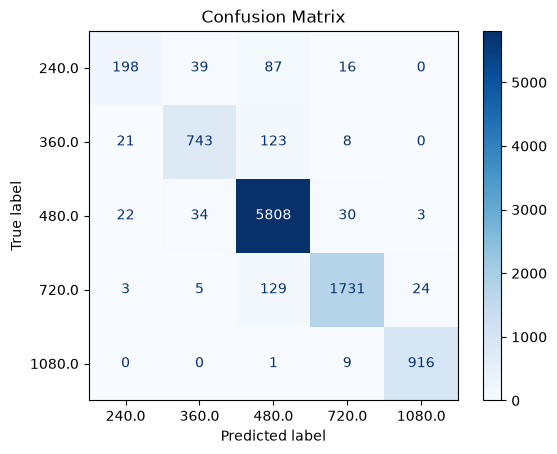

ROC AUC (macro, OvR): 0.9936870574852185


In [13]:
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

y_pred = best_clf.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# F1 Score (macro, since this is multi-class)
print("F1 (macro):", f1_score(y_test, y_pred, average='macro'))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=best_clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=best_clf.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC/AUC — multi-class, one-vs-rest
y_test_bin = label_binarize(y_test, classes=best_clf.classes_)
y_score = best_clf.predict_proba(X_test)
auc = roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovr')
print("ROC AUC (macro, OvR):", auc)

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

C:\Users\Yosan\AppData\Local\Temp\ipykernel_31992\1074571312.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  session = pickle.load(f)


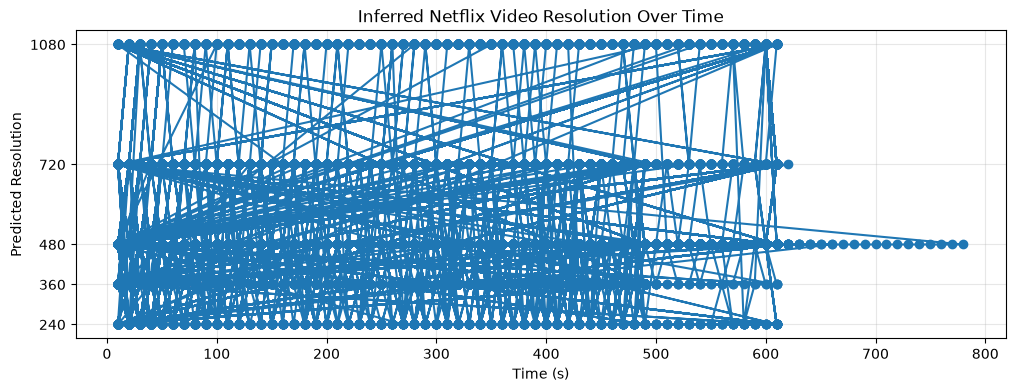

In [16]:
import pickle
import matplotlib.pyplot as plt

with open('../notebooks/data/netflix_dataset.pkl', 'rb') as f:
    session = pickle.load(f)

session.head()
X_session = session.drop(columns=remove + ['resolution'], errors='ignore')
X_session = X_session[X_train.columns]

predictions = clf.predict(X_session)

# if you have a time/window column to plot against, use it; otherwise use row index * 10s
if 'relative_timestamp' in session.columns:
    time_axis = session['relative_timestamp']
elif 'window' in session.columns:
    time_axis = session['window'] * 10
else:
    time_axis = [i * 10 for i in range(len(predictions))]

plt.figure(figsize=(12, 4))
plt.plot(time_axis, predictions, marker='o', linestyle='-')
plt.xlabel('Time (s)')
plt.ylabel('Predicted Resolution')
plt.title('Inferred Netflix Video Resolution Over Time')
plt.yticks([240, 360, 480, 720, 1080])
plt.grid(True, alpha=0.3)
plt.show()
